In [ ]:
Practical No_7(2)

In [7]:
import pandas as pd
import math
documentA = 'Jupiter is the largest Planet'
documentB = 'Mars is the fourth planet from the Sun'
bagOfWordsA = documentA.split(' ')
bagOfWordsB = documentB.split(' ')
uniqueWords = set(bagOfWordsA).union(set(bagOfWordsB))
numOfWordsA = dict.fromkeys(uniqueWords, 0)
for word in bagOfWordsA:
    numOfWordsA[word] += 1
numOfWordsB = dict.fromkeys(uniqueWords, 0)
for word in bagOfWordsB:
    numOfWordsB[word] += 1
def computeTF(wordDict, bagOfWords):
    tfDict = {}
    bagOfWordsCount = len(bagOfWords)
    for word, count in wordDict.items():
        tfDict[word] = count / float(bagOfWordsCount)
    return tfDict
tfA = computeTF(numOfWordsA, bagOfWordsA)
tfB = computeTF(numOfWordsB, bagOfWordsB)
def computeIDF(documents):
    N = len(documents)
    idfDict = dict.fromkeys(documents[0].keys(), 0)
    for document in documents:
        for word, val in document.items():
            if val > 0:
                idfDict[word] += 1
    for word, val in idfDict.items():
        idfDict[word] = math.log(N / float(val))
    return idfDict
idfs = computeIDF([numOfWordsA, numOfWordsB])
def computeTFIDF(tfBagOfWords, idfs):
    tfidf = {}
    for word, val in tfBagOfWords.items():
        tfidf[word] = val * idfs[word]
    return tfidf
tfidfA = computeTFIDF(tfA, idfs)
tfidfB = computeTFIDF(tfB, idfs)
df = pd.DataFrame([tfidfA, tfidfB], index=["Document A", "Document B"])
print(df)



              fourth   largest   Jupiter    planet  the   is      Mars  \
Document A  0.000000  0.138629  0.138629  0.000000  0.0  0.0  0.000000   
Document B  0.086643  0.000000  0.000000  0.086643  0.0  0.0  0.086643   

                from       Sun    Planet  
Document A  0.000000  0.000000  0.138629  
Document B  0.086643  0.086643  0.000000  


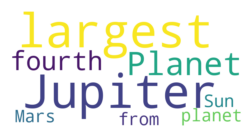

In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
word_freq = {}
for word in df.columns:
    word_freq[word] = tfidfA.get(word, 0) + tfidfB.get(word, 0)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(3, 2))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



In [ ]:
13227 Tanuja Mahajan